# Notebook 7 — Hybrid Model 1: Adaptive Categorical Distribution Balancing
Operates exclusively on `fitness_level` (the only sensitive attribute).
Includes an **inference attack simulation**: attacker predicts the most-frequent class per group.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json, os
import warnings
warnings.filterwarnings('ignore')

os.makedirs('../data', exist_ok=True)
os.makedirs('../results', exist_ok=True)

df          = pd.read_csv('../data/t_close_anonymized.csv')
df_original = pd.read_csv('../data/raw_fitness_data.csv')

quasi_identifiers   = ['age', 'region', 'activity']
sensitive_attribute = 'fitness_level'
fitness_classes     = ['fit', 'moderately_fit', 'unfit']
t_threshold         = 0.25

assert 'fitness_level' in df.columns, 'Run Notebooks 1-4 first.'
print(f'✅ Data loaded — shape: {df.shape}')
print('\nfitness_level distribution:')
print(df['fitness_level'].value_counts())

✅ Data loaded — shape: (7000, 11)

fitness_level distribution:
fitness_level
moderately_fit    4015
fit               1504
unfit             1481
Name: count, dtype: int64


In [2]:
# Population reference distribution (fitness_level only)
pop_fl_dist = df_original['fitness_level'].value_counts(normalize=True)
pop_fl_dist = pop_fl_dist.reindex(fitness_classes, fill_value=0)


def tvd(p, q):
    keys = q.index
    p_a = p.reindex(keys, fill_value=0)
    return 0.5 * sum(abs(p_a[i] - q[i]) for i in keys)


# Baseline violation analysis
violation_rows = []
for gk, gd in df.groupby(quasi_identifiers):
    gd_dist = gd['fitness_level'].value_counts(normalize=True).reindex(fitness_classes, fill_value=0)
    d = tvd(gd_dist, pop_fl_dist)
    violation_rows.append({'group': gk, 'tvd': d, 'violates': d > t_threshold, 'size': len(gd),
                           'fit_pct': float(gd_dist['fit']),
                           'mod_pct': float(gd_dist['moderately_fit']),
                           'unfit_pct': float(gd_dist['unfit'])})

violation_df = pd.DataFrame(violation_rows)
print(f'Baseline — violating groups: {violation_df["violates"].sum()} / {len(violation_df)}')

Baseline — violating groups: 49 / 143


In [3]:
# ---------------------------------------------------------------
# HYBRID 1 — Adaptive strength-scaled distribution balancing
# Correction count is proportional to violation strength.
# Deterministic: sorted by steps, no randomness.
# ---------------------------------------------------------------
def hybrid1_adaptive(df_in, pop_fl, violation_df, quasi_ids, fc):
    df_h = df_in.copy()
    vd = {r['group']: r for _, r in violation_df.iterrows()}
    total_adj = 0
    log = []

    for gk, gd in df_h.groupby(quasi_ids):
        if len(gd) < 4 or gk not in vd or not vd[gk]['violates']:
            continue

        emd = vd[gk]['tvd']
        strength = min(max((emd - t_threshold) / (1.0 - t_threshold), 0), 1.0)
        n_corr   = max(1, int(strength * len(gd) * 0.30))

        gd_dist  = gd['fitness_level'].value_counts(normalize=True).reindex(fc, fill_value=0)
        diff     = gd_dist - pop_fl
        over_c   = diff.idxmax()
        under_c  = diff.idxmin()

        over_rec = gd[gd['fitness_level'] == over_c]
        n_corr   = min(n_corr, max(1, len(over_rec) - 1))

        if under_c == 'fit':
            targets = over_rec.nlargest(n_corr, 'steps').index
        elif under_c == 'unfit':
            targets = over_rec.nsmallest(n_corr, 'steps').index
        else:
            med = over_rec['steps'].median()
            targets = (over_rec['steps'] - med).abs().nsmallest(n_corr).index

        df_h.loc[targets, 'fitness_level'] = under_c
        total_adj += len(targets)
        log.append({'group': gk, 'tvd': emd, 'corrections': len(targets), 'from': over_c, 'to': under_c})

    print(f'✅ Hybrid 1 complete — records adjusted: {total_adj}, groups corrected: {len(log)}')
    return df_h, log


df_h1, adj_log = hybrid1_adaptive(df, pop_fl_dist, violation_df, quasi_identifiers, fitness_classes)

print('\nfitness_level distribution after Hybrid 1:')
print(df_h1['fitness_level'].value_counts())

✅ Hybrid 1 complete — records adjusted: 166, groups corrected: 44

fitness_level distribution after Hybrid 1:
fitness_level
moderately_fit    4168
fit               1420
unfit             1412
Name: count, dtype: int64


In [4]:
# Post-correction violation rate
viol_after = 0
tvd_after  = []
for _, gd in df_h1.groupby(quasi_identifiers):
    gd_dist = gd['fitness_level'].value_counts(normalize=True).reindex(fitness_classes, fill_value=0)
    d = tvd(gd_dist, pop_fl_dist)
    tvd_after.append(d)
    if d > t_threshold:
        viol_after += 1

print(f'Violations remaining: {viol_after} / {len(tvd_after)}')
print(f'Mean TVD: {np.mean(tvd_after):.4f}')

Violations remaining: 39 / 143
Mean TVD: 0.2375


In [5]:
# ---------------------------------------------------------------
# INFERENCE ATTACK SIMULATION
# Attacker strategy: predict the most-frequent fitness_level
#                    class in each equivalence class.
# Accuracy = fraction of records correctly predicted.
# ---------------------------------------------------------------
def inference_attack_accuracy(df_in, quasi_ids):
    correct = 0
    for _, gd in df_in.groupby(quasi_ids):
        predicted_class = gd['fitness_level'].mode().iloc[0]
        correct += (gd['fitness_level'] == predicted_class).sum()
    return correct / len(df_in)


# Compare attack accuracy before and after Hybrid 1
acc_before = inference_attack_accuracy(df, quasi_identifiers)
acc_after  = inference_attack_accuracy(df_h1, quasi_identifiers)

print(f'Inference attack accuracy BEFORE Hybrid 1: {acc_before:.4f} ({100*acc_before:.1f}%)')
print(f'Inference attack accuracy AFTER  Hybrid 1: {acc_after:.4f} ({100*acc_after:.1f}%)')
print(f'Attack accuracy reduction: {100*(acc_before - acc_after):.1f} pp')

Inference attack accuracy BEFORE Hybrid 1: 0.6793 (67.9%)
Inference attack accuracy AFTER  Hybrid 1: 0.6563 (65.6%)
Attack accuracy reduction: 2.3 pp


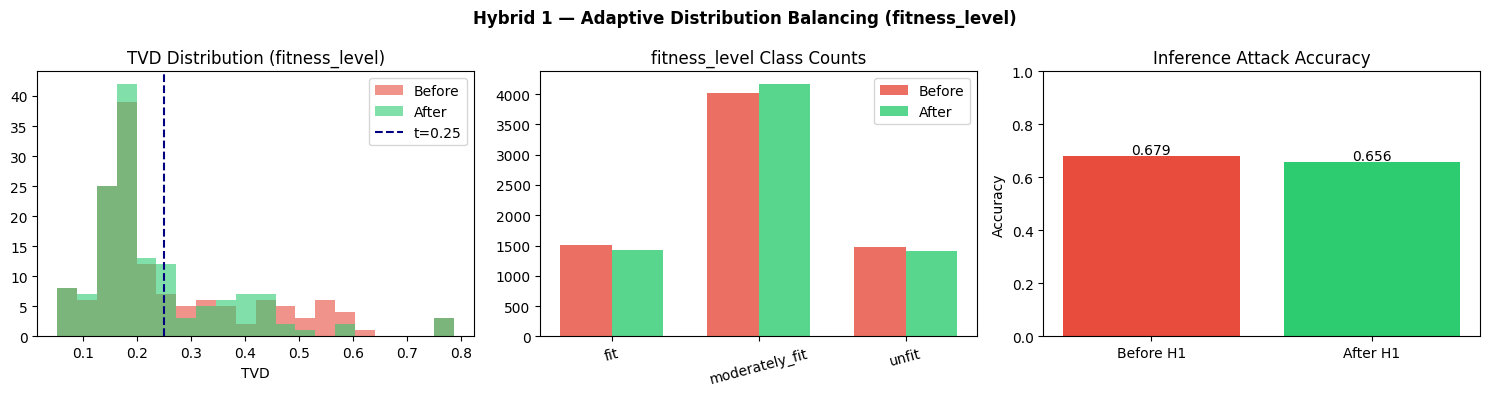

✅ Saved: ../results/hybrid1_analysis.png


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# TVD before/after
tvd_before_vals = violation_df['tvd'].tolist()
axes[0].hist(tvd_before_vals, bins=20, alpha=0.6, color='#e74c3c', label='Before')
axes[0].hist(tvd_after,       bins=20, alpha=0.6, color='#2ecc71', label='After')
axes[0].axvline(x=t_threshold, color='navy', linestyle='--', label=f't={t_threshold}')
axes[0].set_title('TVD Distribution (fitness_level)')
axes[0].set_xlabel('TVD'); axes[0].legend()

# fitness_level distribution before/after
x = np.arange(3)
w = 0.35
before_counts = df['fitness_level'].value_counts().reindex(fitness_classes).values
after_counts  = df_h1['fitness_level'].value_counts().reindex(fitness_classes).values
axes[1].bar(x - w/2, before_counts, w, label='Before', color='#e74c3c', alpha=0.8)
axes[1].bar(x + w/2, after_counts,  w, label='After',  color='#2ecc71', alpha=0.8)
axes[1].set_xticks(x); axes[1].set_xticklabels(fitness_classes, rotation=15)
axes[1].set_title('fitness_level Class Counts')
axes[1].legend()

# Inference attack accuracy
axes[2].bar(['Before H1', 'After H1'], [acc_before, acc_after], color=['#e74c3c', '#2ecc71'])
axes[2].set_ylim(0, 1)
axes[2].set_title('Inference Attack Accuracy')
axes[2].set_ylabel('Accuracy')
for i, v in enumerate([acc_before, acc_after]):
    axes[2].text(i, v + 0.01, f'{v:.3f}', ha='center')

plt.suptitle('Hybrid 1 — Adaptive Distribution Balancing (fitness_level)', fontweight='bold')
plt.tight_layout()
plt.savefig('../results/hybrid1_analysis.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Saved: ../results/hybrid1_analysis.png')

In [7]:
df_h1.to_csv('../data/hybrid1_result.csv', index=False)
print('✅ Saved: ../data/hybrid1_result.csv')

h1_metrics = {
    'method': 'Hybrid 1 — Adaptive Distribution Balancing',
    'sensitive_attribute': 'fitness_level',
    'inference_attack_accuracy': float(acc_after),
    'inference_attack_accuracy_before': float(acc_before),
    'attack_accuracy_reduction': float(acc_before - acc_after),
    'violations_after': viol_after,
    'mean_tvd': float(np.mean(tvd_after)),
    'total_adjustments': sum(r['corrections'] for r in adj_log),
    'data_loss_percent': 0.0
}

with open('../results/hybrid1_metrics.json', 'w') as f:
    json.dump(h1_metrics, f, indent=2)

print('\nHybrid 1 summary:')
for k, v in h1_metrics.items():
    print(f'  {k}: {v}')

✅ Saved: ../data/hybrid1_result.csv

Hybrid 1 summary:
  method: Hybrid 1 — Adaptive Distribution Balancing
  sensitive_attribute: fitness_level
  inference_attack_accuracy: 0.6562857142857143
  inference_attack_accuracy_before: 0.6792857142857143
  attack_accuracy_reduction: 0.02300000000000002
  violations_after: 39
  mean_tvd: 0.23745046467937705
  total_adjustments: 166
  data_loss_percent: 0.0
